In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/consumption/1pasos_mlp_consumption.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2017-11-24 23:10:00,-0.308303,-0.229034
2017-11-24 23:20:00,-0.403297,-0.329750
2017-11-24 23:30:00,-0.525433,-0.437478
2017-11-24 23:40:00,-0.616186,-0.578133
2017-11-24 23:50:00,-0.689976,-0.665953


In [3]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/consumption/1pasos_lstm_consumption.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2017-11-24 23:10:00,-0.308303,-0.210721
2017-11-24 23:20:00,-0.403297,-0.328352
2017-11-24 23:30:00,-0.525433,-0.442928
2017-11-24 23:40:00,-0.616186,-0.594140
2017-11-24 23:50:00,-0.689976,-0.695266


In [4]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/consumption/1pasos_gru_consumption.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2017-11-24 23:10:00,-0.308303,-0.261955
2017-11-24 23:20:00,-0.403297,-0.365560
2017-11-24 23:30:00,-0.525433,-0.464747
2017-11-24 23:40:00,-0.616186,-0.593218
2017-11-24 23:50:00,-0.689976,-0.683690


In [5]:
datosCross= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/consumption/crossformerConsumption.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.153065
2017-11-25 01:10:00,-1.293020,-1.188033
2017-11-25 01:20:00,-1.333732,-1.306982
2017-11-25 01:30:00,-1.353240,-1.322111
2017-11-25 01:40:00,-1.345607,-1.330723


In [6]:
datosI= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/consumption/itransformerConsumption.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2017-11-25 01:00:00,-1.185304,-1.164902
2017-11-25 01:10:00,-1.293020,-1.207155
2017-11-25 01:20:00,-1.333732,-1.322870
2017-11-25 01:30:00,-1.353240,-1.358101
2017-11-25 01:40:00,-1.345607,-1.372037


In [7]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/1paso/consumption/tftConsumption.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2017-11-23 22:50:00,-0.158178,-0.112981
2017-11-23 23:00:00,-0.311695,-0.242561
2017-11-23 23:10:00,-0.391423,-0.419724
2017-11-23 23:20:00,-0.466909,-0.455216
2017-11-23 23:30:00,-0.561055,-0.510299


In [8]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])



In [9]:
final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-23 22:50:00,NaN,NaN,NaN,NaN,NaN,-0.045197
2017-11-23 23:00:00,NaN,NaN,NaN,NaN,NaN,-0.069135
2017-11-23 23:10:00,NaN,NaN,NaN,NaN,NaN,0.028301
2017-11-23 23:20:00,NaN,NaN,NaN,NaN,NaN,-0.011693
2017-11-23 23:30:00,NaN,NaN,NaN,NaN,NaN,-0.050757


In [10]:
final = final.dropna()
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-25 01:00:00,-0.007819,0.023316,0.006825,-0.032238,-0.020401,-0.047442
2017-11-25 01:10:00,-0.097095,-0.074770,-0.083098,-0.104988,-0.085866,-0.110064
2017-11-25 01:20:00,-0.007500,0.012178,0.003351,-0.026750,-0.010862,0.031103
2017-11-25 01:30:00,-0.014987,0.028630,-0.008076,-0.031129,0.004861,-0.012507
2017-11-25 01:40:00,0.009566,0.040283,0.015815,-0.014883,0.026430,0.023165


Muestra aleatoria

In [11]:
final = final.sample(frac=0.10, random_state=42)

In [12]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [13]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print(p)


3.164423603928942e-96


In [14]:
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print(p)


2.9458254051252046e-98


In [15]:
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print(p)


2.8286392980918544e-99


In [16]:
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print(p)


7.726192449066507e-101


In [17]:
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print(p)


7.980085759253185e-97


In [18]:
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print(p)


2.1279221354703525e-101


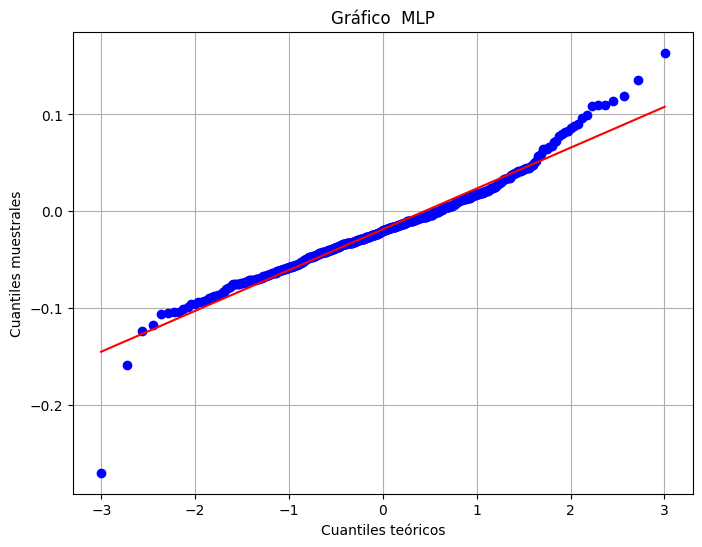

In [19]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP"], dist="norm", plot=plt)
plt.title('Gráfico  MLP')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

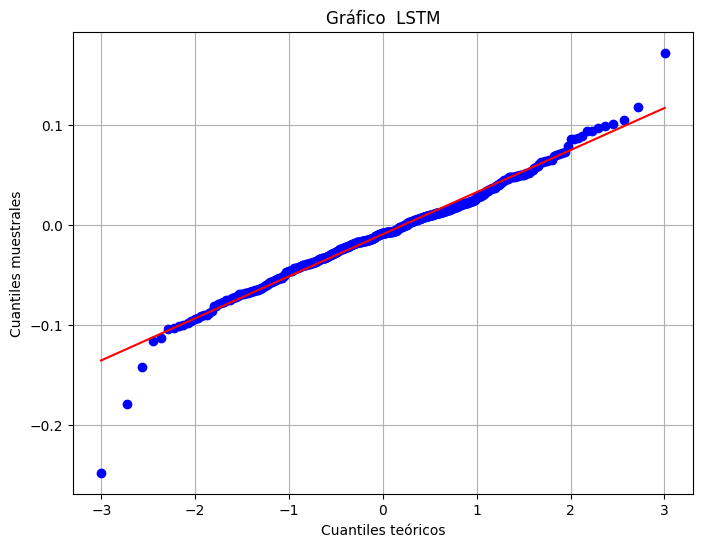

In [20]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM"], dist="norm", plot=plt)
plt.title('Gráfico  LSTM')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

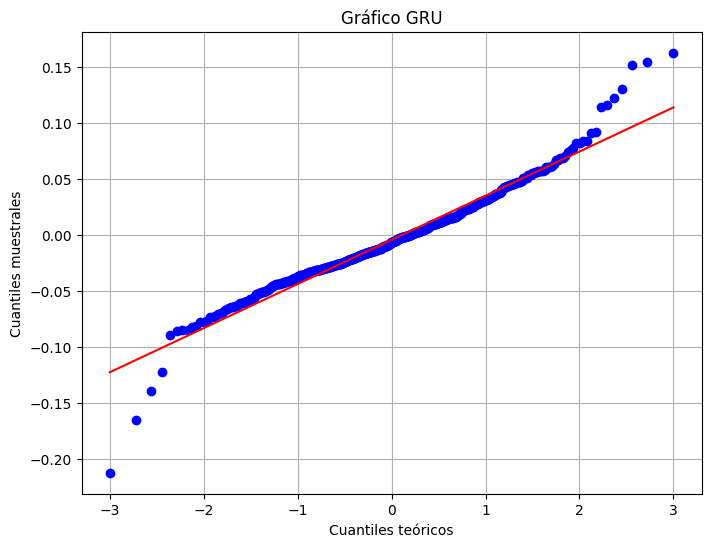

In [21]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU"], dist="norm", plot=plt)
plt.title('Gráfico GRU')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

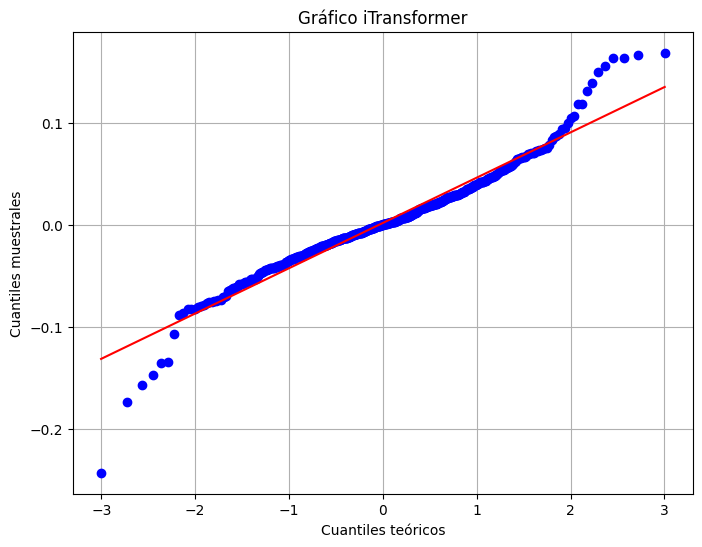

In [22]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer"], dist="norm", plot=plt)
plt.title('Gráfico iTransformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

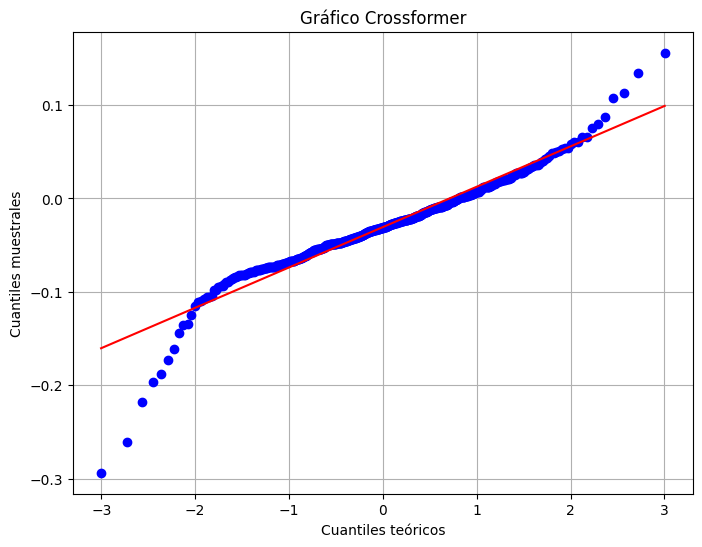

In [23]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer"], dist="norm", plot=plt)
plt.title('Gráfico Crossformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

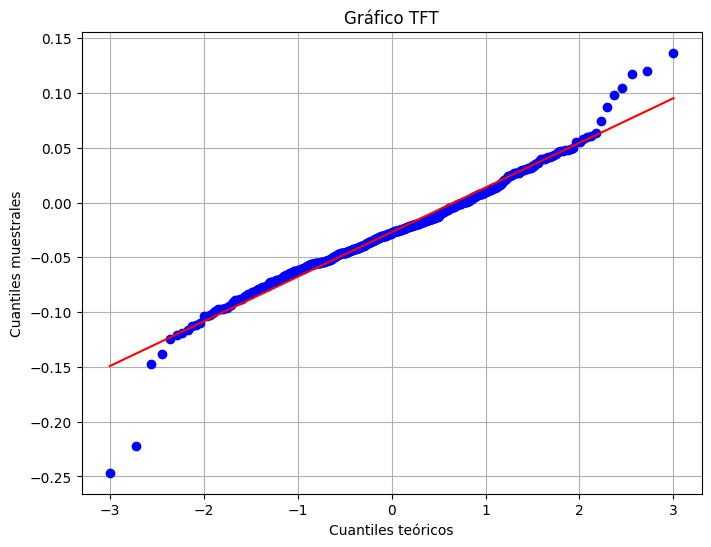

In [24]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT"], dist="norm", plot=plt)
plt.title('Gráfico TFT')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

In [25]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

2.7228912197015578e-167


In [26]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.00000,0.00000,0.00000
1,MLP vs GRU,0.00000,0.00000,0.00000
2,MLP vs Crossformer,0.00000,0.00000,0.00000
3,MLP vs iTransformer,0.00000,0.00000,0.00000
4,MLP vs TFT,0.00000,0.00000,0.00000
5,LSTM vs GRU,0.00509,0.07642,0.00509
6,LSTM vs Crossformer,0.00000,0.00000,0.00000
7,LSTM vs iTransformer,0.00000,0.00000,0.00000
8,LSTM vs TFT,0.00000,0.00000,0.00000
9,GRU vs Crossformer,0.00000,0.00000,0.00000
